In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [17]:

colunas = [
    'NU_INSCRICAO', 'NU_ANO', 'TP_FAIXA_ETARIA', 'TP_SEXO',
    'TP_COR_RACA', 'TP_ST_CONCLUSAO', 'TP_ESCOLA', 'TP_ENSINO',
    'NO_MUNICIPIO_ESC', 'CO_UF_ESC', 'SG_UF_ESC',
    'TP_DEPENDENCIA_ADM_ESC', 'TP_LOCALIZACAO_ESC', 'TP_SIT_FUNC_ESC',
    'TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC',
    'TP_PRESENCA_MT', 'TP_LINGUA', 'NU_NOTA_CN', 'NU_NOTA_CH',
    'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO'
]
df = pd.read_csv("MICRODADOS_ENEM_2023.csv", sep=";", encoding="ISO-8859-1", usecols=colunas)
df.head()

,NU_INSCRICAO,NU_ANO,TP_FAIXA_ETARIA,TP_SEXO,TP_COR_RACA,TP_ST_CONCLUSAO,TP_ESCOLA,TP_ENSINO,NO_MUNICIPIO_ESC,CO_UF_ESC,...,TP_PRESENCA_CN,TP_PRESENCA_CH,TP_PRESENCA_LC,TP_PRESENCA_MT,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,TP_LINGUA,NU_NOTA_REDACAO
0,210059085136,2023,14,M,1,1,1,NaN,NaN,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN
1,210059527735,2023,12,M,1,1,1,NaN,NaN,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,0,NaN
2,210061103945,2023,6,F,1,1,1,NaN,NaN,NaN,...,1,1,1,1,502.0,498.9,475.6,363.2,1,700.0
3,210060214087,2023,2,F,3,2,2,1.0,Fortaleza,23.0,...,1,1,1,1,459.0,508.5,507.2,466.7,0,880.0
4,210059980948,2023,3,F,3,2,2,1.0,Quixadá,23.0,...,1,1,1,1,402.5,379.2,446.9,338.3,0,560.0


In [19]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3933955 entries, 0 to 3933954
Data columns (total 24 columns):
 #   Column                  Dtype  
---  ------                  -----  
 0   NU_INSCRICAO            int64  
 1   NU_ANO                  int64  
 2   TP_FAIXA_ETARIA         int64  
 3   TP_SEXO                 str    
 4   TP_COR_RACA             int64  
 5   TP_ST_CONCLUSAO         int64  
 6   TP_ESCOLA               int64  
 7   TP_ENSINO               float64
 8   NO_MUNICIPIO_ESC        str    
 9   CO_UF_ESC               float64
 10  SG_UF_ESC               str    
 11  TP_DEPENDENCIA_ADM_ESC  float64
 12  TP_LOCALIZACAO_ESC      float64
 13  TP_SIT_FUNC_ESC         float64
 14  TP_PRESENCA_CN          int64  
 15  TP_PRESENCA_CH          int64  
 16  TP_PRESENCA_LC          int64  
 17  TP_PRESENCA_MT          int64  
 18  NU_NOTA_CN              float64
 19  NU_NOTA_CH              float64
 20  NU_NOTA_LC              float64
 21  NU_NOTA_MT              float64
 22  TP_LI

In [20]:
df.isnull().sum()

NU_INSCRICAO                    0
NU_ANO                          0
TP_FAIXA_ETARIA                 0
TP_SEXO                         0
TP_COR_RACA                     0
TP_ST_CONCLUSAO                 0
TP_ESCOLA                       0
TP_ENSINO                 2594874
NO_MUNICIPIO_ESC          2975449
CO_UF_ESC                 2975449
SG_UF_ESC                 2975449
TP_DEPENDENCIA_ADM_ESC    2975449
TP_LOCALIZACAO_ESC        2975449
TP_SIT_FUNC_ESC           2975449
TP_PRESENCA_CN                  0
TP_PRESENCA_CH                  0
TP_PRESENCA_LC                  0
TP_PRESENCA_MT                  0
NU_NOTA_CN                1241528
NU_NOTA_CH                1111312
NU_NOTA_LC                1111312
NU_NOTA_MT                1241528
TP_LINGUA                       0
NU_NOTA_REDACAO           1111312
dtype: int64

In [6]:
notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

df[notas].describe().round(2)

,NU_NOTA_CN,NU_NOTA_CH,NU_NOTA_LC,NU_NOTA_MT,NU_NOTA_REDACAO
count,2692427.00,2822643.00,2822643.00,2692427.00,2822643.00
mean,495.75,523.35,518.15,533.84,617.80
std,87.93,88.57,75.45,131.65,214.62
min,0.00,0.00,0.00,0.00,0.00
25%,440.50,467.80,471.40,431.20,500.00
50%,493.90,530.40,523.10,523.60,620.00
75%,551.20,584.90,570.30,630.10,780.00
max,868.40,823.00,820.80,958.60,1000.00


# Distribuição notas

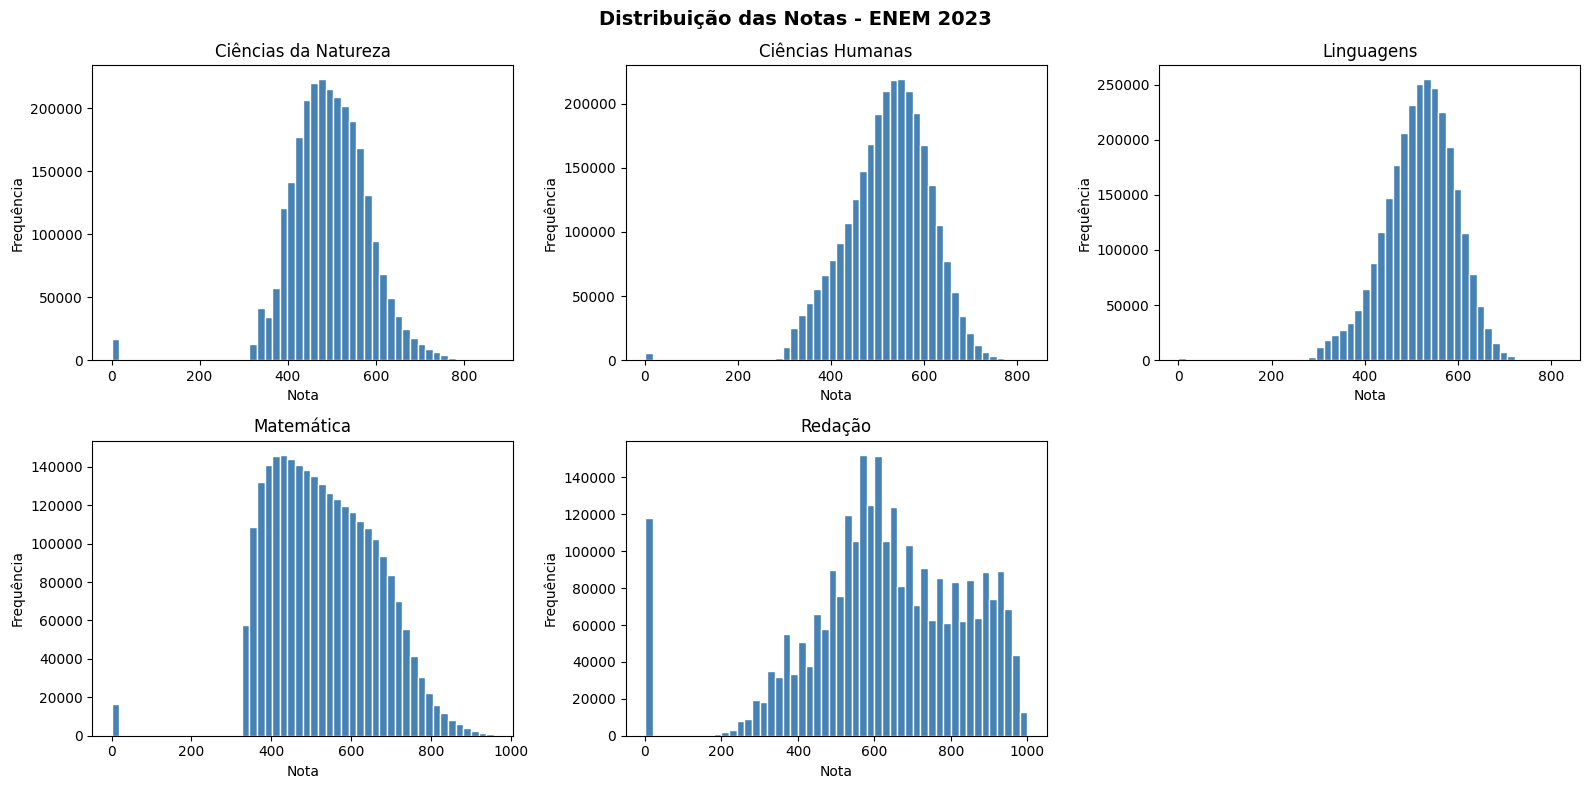

In [7]:
fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

titulos = ['Ciências da Natureza', 'Ciências Humanas', 'Linguagens', 'Matemática', 'Redação']

for i, (col, titulo) in enumerate(zip(notas, titulos)):
    axes[i].hist(df[col].dropna(), bins=50, color='steelblue', edgecolor='white')
    axes[i].set_title(titulo)
    axes[i].set_xlabel('Nota')
    axes[i].set_ylabel('Frequência')

axes[-1].set_visible(False)
plt.suptitle('Distribuição das Notas - ENEM 2023', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Presença

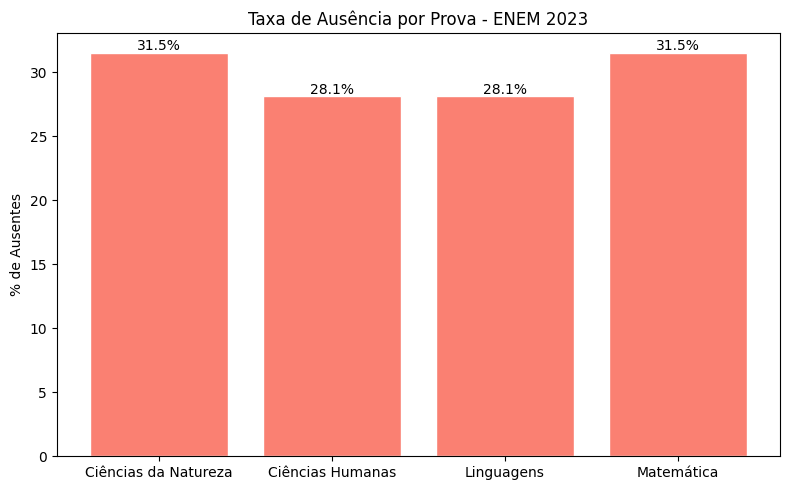

In [8]:
presenca_cols = ['TP_PRESENCA_CN', 'TP_PRESENCA_CH', 'TP_PRESENCA_LC', 'TP_PRESENCA_MT']
provas = ['Ciências da Natureza', 'Ciências Humanas', 'Linguagens', 'Matemática']

# 0 = ausente, 1 = presente, 2 = eliminado
ausencia = [(df[col] == 0).mean() * 100 for col in presenca_cols]

plt.figure(figsize=(8, 5))
bars = plt.bar(provas, ausencia, color='salmon', edgecolor='white')
plt.ylabel('% de Ausentes')
plt.title('Taxa de Ausência por Prova - ENEM 2023')
for bar, val in zip(bars, ausencia):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.2, f'{val:.1f}%', ha='center')
plt.tight_layout()
plt.show()

# Média por sexo

In [9]:
sexo_map = {'M': 'Masculino', 'F': 'Feminino'}
df['TP_SEXO_LABEL'] = df['TP_SEXO'].map(sexo_map)

media_sexo = df.groupby('TP_SEXO_LABEL')[notas].mean().round(2)
media_sexo.columns = titulos
media_sexo

,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
TP_SEXO_LABEL,,,,,
Feminino,487.55,519.90,517.12,516.84,634.93
Masculino,508.76,528.86,519.77,560.80,590.50


# Média por raça

In [10]:
raca_map = {
    0: 'Não declarado', 1: 'Branca', 2: 'Preta',
    3: 'Parda', 4: 'Amarela', 5: 'Indígena', 6: 'Não dispõe'
}
df['TP_COR_RACA_LABEL'] = df['TP_COR_RACA'].map(raca_map)

media_raca = df.groupby('TP_COR_RACA_LABEL')[notas].mean().round(2)
media_raca.columns = titulos
media_raca

,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
TP_COR_RACA_LABEL,,,,,
Amarela,497.49,515.90,510.95,537.75,603.86
Branca,516.46,544.75,537.60,571.32,660.78
Indígena,453.14,476.91,474.05,462.39,511.86
Não declarado,500.38,527.44,519.84,535.37,597.64
Parda,480.68,507.47,503.68,507.49,589.17
Preta,474.74,504.85,501.78,492.91,572.51


# Tipo de escola

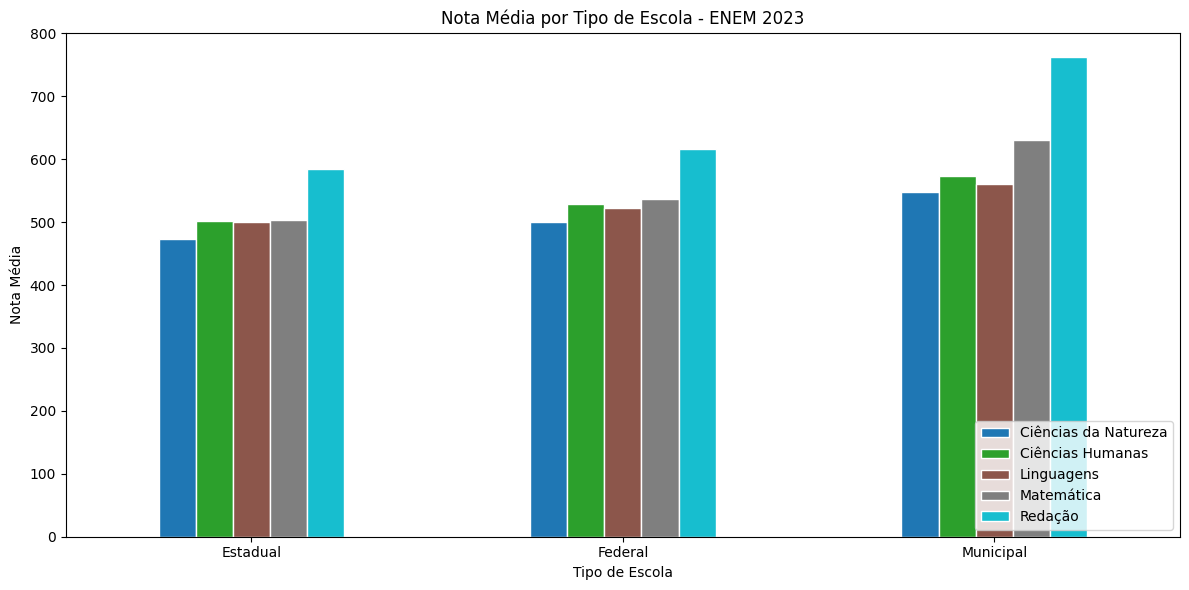

In [11]:
escola_map = {1: 'Federal', 2: 'Estadual', 3: 'Municipal', 4: 'Privada'}
df['TP_ESCOLA_LABEL'] = df['TP_ESCOLA'].map(escola_map)

media_escola = df.groupby('TP_ESCOLA_LABEL')[notas].mean().round(2)
media_escola.columns = titulos

media_escola.plot(kind='bar', figsize=(12, 6), colormap='tab10', edgecolor='white')
plt.title('Nota Média por Tipo de Escola - ENEM 2023')
plt.ylabel('Nota Média')
plt.xlabel('Tipo de Escola')
plt.xticks(rotation=0)
plt.legend(loc='lower right')
plt.tight_layout()
plt.show()

# Média por estado

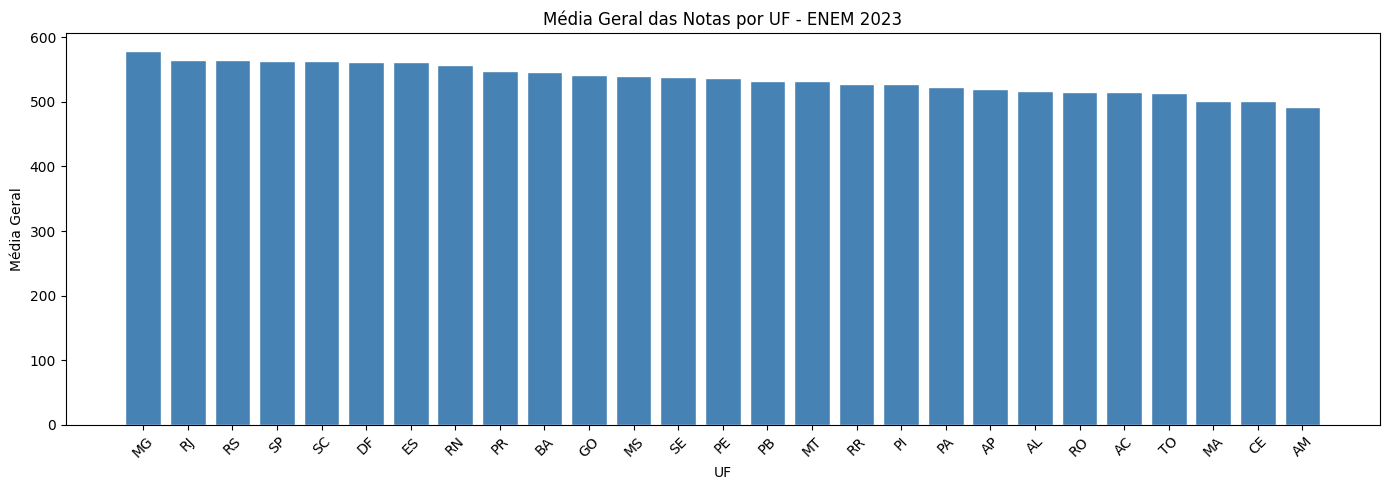

In [12]:
media_uf = df.groupby('SG_UF_ESC')[notas].mean().round(2)
media_uf['MEDIA_GERAL'] = media_uf.mean(axis=1)
media_uf = media_uf.sort_values('MEDIA_GERAL', ascending=False)

plt.figure(figsize=(14, 5))
plt.bar(media_uf.index, media_uf['MEDIA_GERAL'], color='steelblue', edgecolor='white')
plt.title('Média Geral das Notas por UF - ENEM 2023')
plt.ylabel('Média Geral')
plt.xlabel('UF')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Média por faixa etária

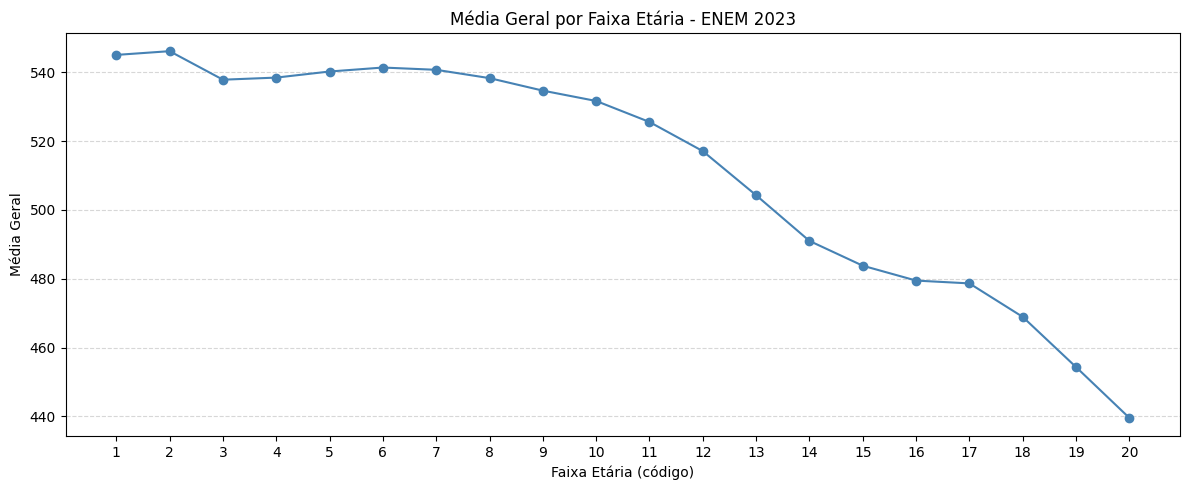

In [13]:
faixa_map = {
    1: 'Menor de 17', 2: '17', 3: '18', 4: '19', 5: '20',
    6: '21-24', 7: '25-29', 8: '30-34', 9: '35-39',
    10: '40-44', 11: '45-49', 12: '50-54', 13: '55-59',
    14: '60-64', 15: '65-69', 16: '70+'
}
df['TP_FAIXA_ETARIA_LABEL'] = df['TP_FAIXA_ETARIA'].map(faixa_map)

media_faixa = df.groupby('TP_FAIXA_ETARIA')[notas].mean().round(2)
media_faixa['MEDIA_GERAL'] = media_faixa.mean(axis=1)

plt.figure(figsize=(12, 5))
plt.plot(media_faixa.index, media_faixa['MEDIA_GERAL'], marker='o', color='steelblue')
plt.title('Média Geral por Faixa Etária - ENEM 2023')
plt.ylabel('Média Geral')
plt.xlabel('Faixa Etária (código)')
plt.xticks(media_faixa.index)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

# Correlação entre as notas

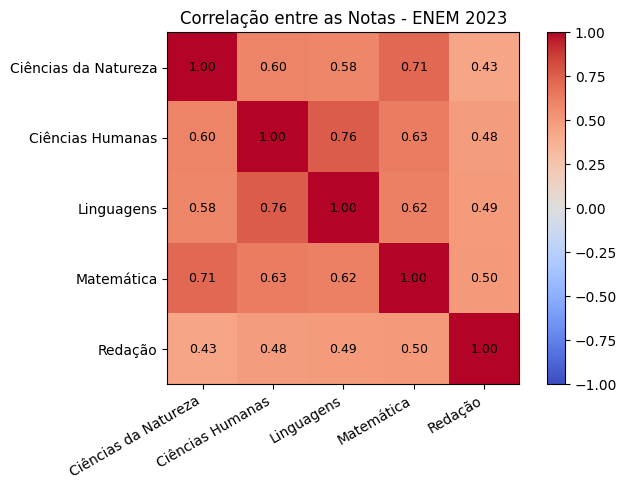

In [14]:
plt.figure(figsize=(7, 5))
correlacao = df[notas].corr()

import matplotlib.patches as mpatches

im = plt.imshow(correlacao, cmap='coolwarm', vmin=-1, vmax=1)
plt.colorbar(im)
plt.xticks(range(len(titulos)), titulos, rotation=30, ha='right')
plt.yticks(range(len(titulos)), titulos)

for i in range(len(titulos)):
    for j in range(len(titulos)):
        plt.text(j, i, f'{correlacao.iloc[i, j]:.2f}', ha='center', va='center', fontsize=9)

plt.title('Correlação entre as Notas - ENEM 2023')
plt.tight_layout()
plt.show()

# Média por localidade da escola

In [15]:
local_map = {1: 'Urbana', 2: 'Rural'}
df['TP_LOCALIZACAO_LABEL'] = df['TP_LOCALIZACAO_ESC'].map(local_map)

media_local = df.groupby('TP_LOCALIZACAO_LABEL')[notas].mean().round(2)
media_local.columns = titulos
media_local

,Ciências da Natureza,Ciências Humanas,Linguagens,Matemática,Redação
TP_LOCALIZACAO_LABEL,,,,,
Rural,470.33,491.58,487.43,496.45,565.59
Urbana,498.93,525.13,520.84,548.70,635.75


# Taxa de ausência por prova (antes de filtrar)

In [22]:
presenca_cols = {
    'TP_PRESENCA_CN': 'Ciências da Natureza',
    'TP_PRESENCA_CH': 'Ciências Humanas',
    'TP_PRESENCA_LC': 'Linguagens',
    'TP_PRESENCA_MT': 'Matemática'
}

for col, nome in presenca_cols.items():
    ausentes = (df[col] == 0).sum()
    total = len(df)
    print(f"{nome}: {ausentes:,} ausentes ({ausentes/total*100:.1f}%)")

print(f"\nTotal de registros antes do filtro: {len(df):,}")

Ciências da Natureza: 1,239,316 ausentes (31.5%)
Ciências Humanas: 1,106,714 ausentes (28.1%)
Linguagens: 1,106,714 ausentes (28.1%)
Matemática: 1,239,316 ausentes (31.5%)

Total de registros antes do filtro: 3,933,955


In [23]:
notas = ['NU_NOTA_CN', 'NU_NOTA_CH', 'NU_NOTA_LC', 'NU_NOTA_MT', 'NU_NOTA_REDACAO']

df_presentes = df.dropna(subset=notas).copy()

print(f"Registros antes : {len(df):,}")
print(f"Registros depois: {len(df_presentes):,}")
print(f"Removidos       : {len(df) - len(df_presentes):,} ({(1 - len(df_presentes)/len(df))*100:.1f}%)")

Registros antes : 3,933,955
Registros depois: 2,678,264
Removidos       : 1,255,691 (31.9%)
